In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

print("Environment working!")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Rasterio:", rasterio.__version__)

Matplotlib is building the font cache; this may take a moment.


Environment working!
NumPy: 2.5.2
Pandas: 3.0.5
Rasterio: 1.5.1


In [3]:
import os

print("Exists:", os.path.exists(sar_path))
print("Is file:", os.path.isfile(sar_path))
print("Is directory:", os.path.isdir(sar_path))

if os.path.exists(sar_path):
    print("Size:", os.path.getsize(sar_path), "bytes")

Exists: True
Is file: False
Is directory: True
Size: 4096 bytes


In [4]:
sar_path = "../../data/sar/sar_sample_01.tiff/S1A_IW_GRDH_1SDV_20211013T064329_20211013T064354_040097_04BF7D_66FF.tiff"

In [8]:
import os

folder = "../../data/sar/sar_samples"

print("Folder exists:", os.path.isdir(folder))
print("\nFiles inside:")

for file in os.listdir(folder):
    print(file)

Folder exists: True

Files inside:
merged.png
S1A_IW_GRDH_1SDV_20200723T061222_20200723T061247_033578_03E42D_AD34.tiff
S1A_IW_GRDH_1SDV_20200724T111906_20200724T111931_033596_03E4C4_3F32.tiff
S1A_IW_GRDH_1SDV_20200724T144206_20200724T144231_033598_03E4D2_FB16.tiff
S1A_IW_GRDH_1SDV_20200729T180154_20200729T180219_033673_03E712_CAF6.tiff
S1A_IW_GRDH_1SDV_20211013T064329_20211013T064354_040097_04BF7D_66FF.tiff


In [9]:
import glob

tiff_files = glob.glob("../../data/sar/sar_samples/*.tiff")

print("Number of TIFF files:", len(tiff_files))

for file in tiff_files:
    print(file)

Number of TIFF files: 5
../../data/sar/sar_samples\S1A_IW_GRDH_1SDV_20200723T061222_20200723T061247_033578_03E42D_AD34.tiff
../../data/sar/sar_samples\S1A_IW_GRDH_1SDV_20200724T111906_20200724T111931_033596_03E4C4_3F32.tiff
../../data/sar/sar_samples\S1A_IW_GRDH_1SDV_20200724T144206_20200724T144231_033598_03E4D2_FB16.tiff
../../data/sar/sar_samples\S1A_IW_GRDH_1SDV_20200729T180154_20200729T180219_033673_03E712_CAF6.tiff
../../data/sar/sar_samples\S1A_IW_GRDH_1SDV_20211013T064329_20211013T064354_040097_04BF7D_66FF.tiff


In [10]:
sar_path = tiff_files[0]

print("Using:", sar_path)

Using: ../../data/sar/sar_samples\S1A_IW_GRDH_1SDV_20200723T061222_20200723T061247_033578_03E42D_AD34.tiff


In [11]:
with rasterio.open(sar_path) as src:
    sar = src.read(1)

print("Shape:", sar.shape)
print("Minimum:", np.min(sar))
print("Maximum:", np.max(sar))

Shape: (4167, 6657)
Minimum: 0
Maximum: 255


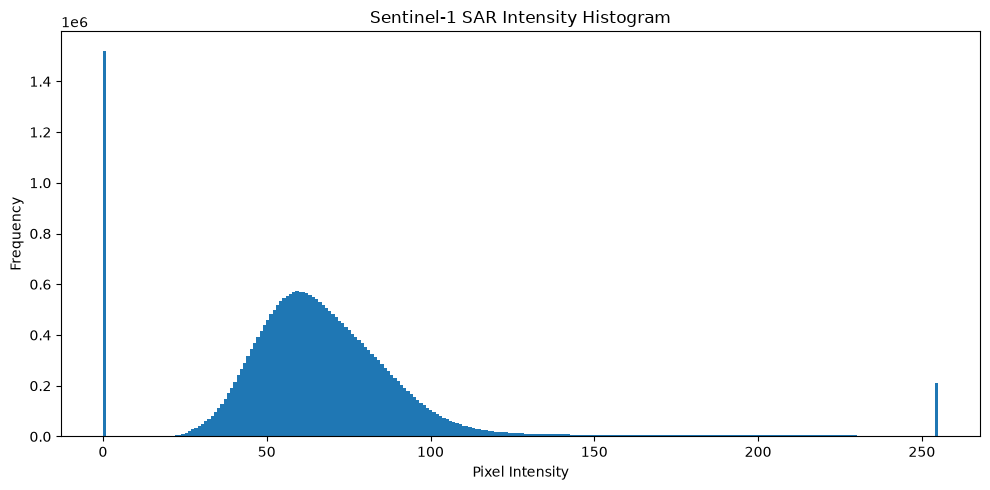

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(sar.flatten(), bins=256)

plt.title("Sentinel-1 SAR Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

ais_path = "../../data/ais/ais-2025-01-08.csv.zst"

ais = pd.read_csv(
    ais_path,
    compression="zstd",
    nrows=100000
)

print("Rows:", len(ais))
print("Columns:")
print(ais.columns.tolist())

Rows: 100000
Columns:
['mmsi', 'base_date_time', 'longitude', 'latitude', 'sog', 'cog', 'heading', 'vessel_name', 'imo', 'call_sign', 'vessel_type', 'status', 'length', 'width', 'draft', 'cargo', 'transceiver']


In [17]:
import matplotlib.pyplot as plt

# Convert timestamp
ais["base_date_time"] = pd.to_datetime(ais["base_date_time"])

# Remove rows with missing coordinates
ais_map = ais.dropna(subset=["longitude", "latitude"]).copy()

print("Rows available for mapping:", len(ais_map))
print("Longitude range:", ais_map["longitude"].min(), "to", ais_map["longitude"].max())
print("Latitude range:", ais_map["latitude"].min(), "to", ais_map["latitude"].max())

Rows available for mapping: 100000
Longitude range: -160.44088 to -63.51013
Latitude range: 14.54614 to 49.81988


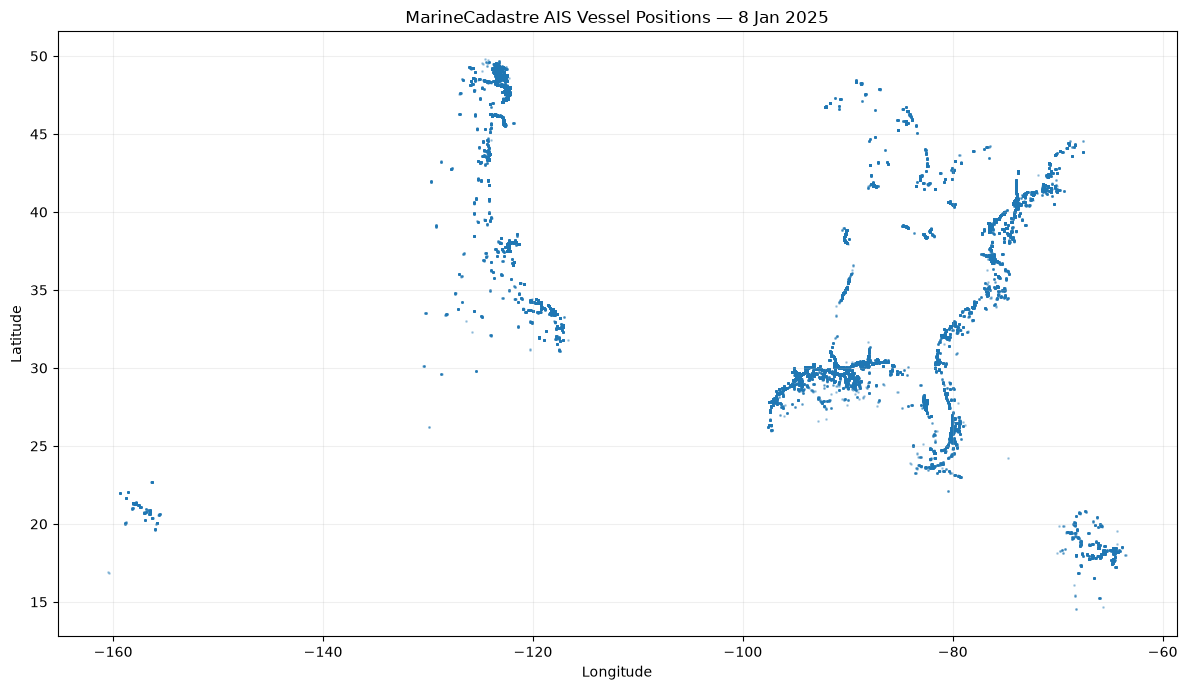

In [18]:
plt.figure(figsize=(12, 7))

plt.scatter(
    ais_map["longitude"],
    ais_map["latitude"],
    s=1,
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("MarineCadastre AIS Vessel Positions — 8 Jan 2025")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [19]:
pd.read_csv(
    "../../data/ais/ais-2025-01-08.csv.zst",
    compression="zstd",
    nrows=100000
)

,mmsi,base_date_time,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
0,367793030,2025-01-08 00:00:00,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
1,338160209,2025-01-08 00:00:00,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B
2,266283000,2025-01-08 00:00:01,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A
3,368013620,2025-01-08 00:00:10,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B
4,368144150,2025-01-08 00:00:09,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,367362960,2025-01-08 00:25:03,-90.55324,30.04806,2.7,270.4,276.0,ST PADRE PIO,IMO8731318,WDE5168,31.0,12.0,146.0,22.0,2.8,57.0,A
99996,338461515,2025-01-08 00:17:37,-77.81275,34.21726,0.0,356.6,209.0,BUCKETLIST,NaN,NaN,30.0,NaN,18.0,5.0,NaN,NaN,B
99997,367004280,2025-01-08 00:23:53,-90.99711,30.16110,0.0,83.9,NaN,CSS RICHMOND,NaN,WDC3231,31.0,0.0,16.0,7.0,2.4,57.0,A
99998,538071476,2025-01-08 00:24:16,-64.92065,18.33483,0.0,71.8,71.0,KISMET,IMO9881627,V7A2834,37.0,5.0,122.0,17.0,4.4,37.0,A


In [20]:
# Prepare AIS data for track visualization

ais["base_date_time"] = pd.to_datetime(ais["base_date_time"])

ais_track = ais.dropna(
    subset=["mmsi", "base_date_time", "longitude", "latitude"]
).copy()

# Sort by vessel and time
ais_track = ais_track.sort_values(
    ["mmsi", "base_date_time"]
)

print("Valid AIS records:", len(ais_track))
print("Unique vessels:", ais_track["mmsi"].nunique())

Valid AIS records: 100000
Unique vessels: 12171


Selected MMSI: 366990560
Number of observations: 26


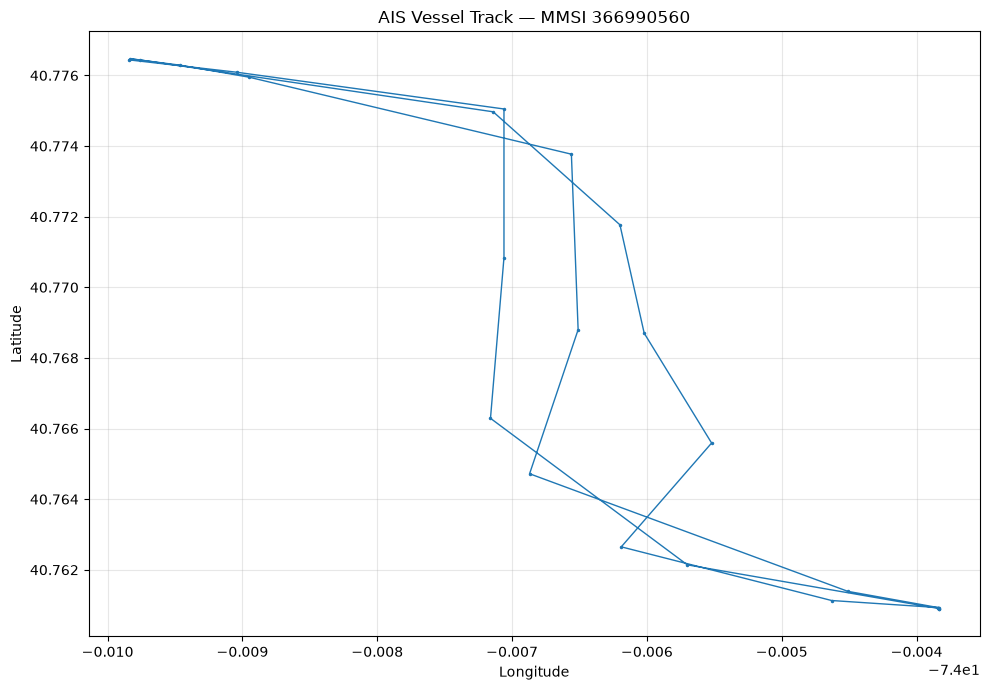

In [23]:
# Select the vessel with the most observations
main_mmsi = vessel_counts.index[0]

vessel = ais_track[
    ais_track["mmsi"] == main_mmsi
].sort_values("base_date_time")

print("Selected MMSI:", main_mmsi)
print("Number of observations:", len(vessel))

# Plot the vessel track
plt.figure(figsize=(10, 7))

plt.plot(
    vessel["longitude"],
    vessel["latitude"],
    marker=".",
    markersize=3,
    linewidth=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"AIS Vessel Track — MMSI {int(main_mmsi)}")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()